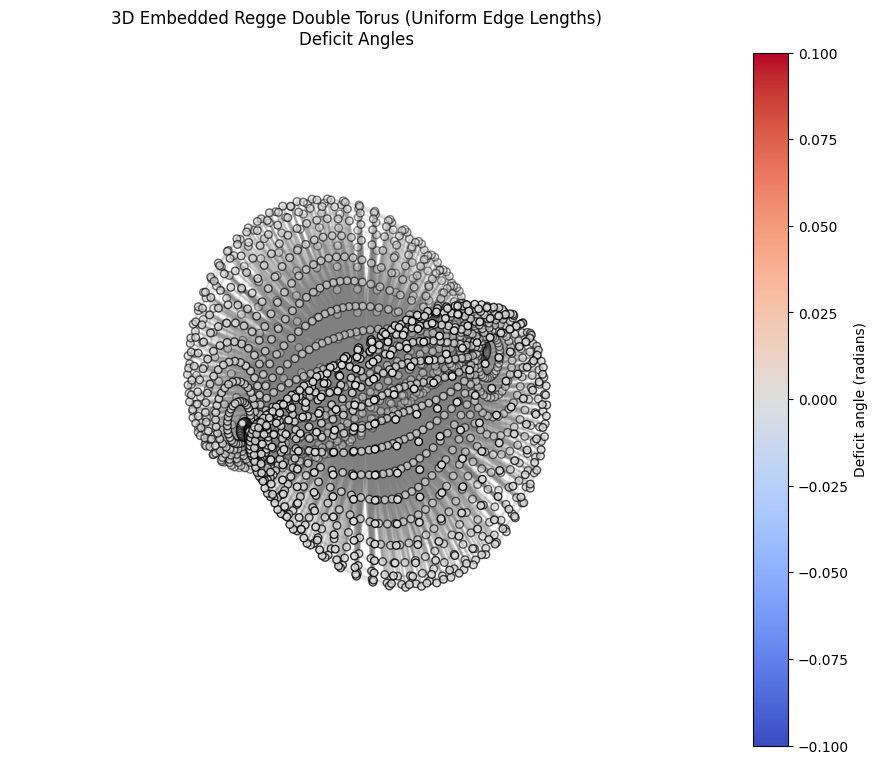

Vertices: 1800, Faces: 3600
Min deficit angle: 0.0
Max deficit angle: 0.0
Sum of all deficit angles (should be ~-4pi for genus 2): 0.0


In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Generate a parametric genus-2 surface ("double torus")
def genus2_surface(u_steps=60, v_steps=30, a=1.0, c=2.0):
    u = np.linspace(0, 2*np.pi, u_steps, endpoint=False)
    v = np.linspace(0, 2*np.pi, v_steps, endpoint=False)
    u, v = np.meshgrid(u, v)
    u = u.ravel()
    v = v.ravel()
    # Parametric "figure-8" surface
    x = (c + a * (np.cos(u) - 0.5 * np.sin(u)) * np.cos(v)) * np.cos(u)
    y = (c + a * (np.cos(u) - 0.5 * np.sin(u)) * np.cos(v)) * np.sin(u)
    z = a * (np.cos(u) - 0.5 * np.sin(u)) * np.sin(v)
    verts = np.vstack([x, y, z]).T

    # Triangulate the grid (periodic)
    faces = []
    for i in range(u_steps):
        for j in range(v_steps):
            a0 = i * v_steps + j
            a1 = ((i+1)%u_steps) * v_steps + j
            a2 = i * v_steps + (j+1)%v_steps
            a3 = ((i+1)%u_steps) * v_steps + (j+1)%v_steps
            faces.append([a0, a1, a2])
            faces.append([a1, a3, a2])
    faces = np.array(faces)
    return verts, faces

verts, faces = genus2_surface(u_steps=60, v_steps=30)
N_points = len(verts)

# --- Assign uniform entanglement to each edge ---
edges = set()
for t in faces:
    for k in range(3):
        a, b = sorted((t[k], t[(k+1)%3]))
        edges.add((a, b))
edges = list(edges)

# Uniform edge lengths everywhere
entanglement = {e: np.exp(-1) for e in edges}  # All edge lengths = 1

def edge_length(E):
    return -np.log(E) if E > 0 else 1e6
edge_lengths = {e: edge_length(entanglement[e]) for e in edges}

# --- Compute vertex angle sums ---
def triangle_angles(lens):
    a, b, c = lens
    argA = np.clip((b**2 + c**2 - a**2) / (2*b*c), -1.0, 1.0)
    argB = np.clip((a**2 + c**2 - b**2) / (2*a*c), -1.0, 1.0)
    angle_A = np.arccos(argA)
    angle_B = np.arccos(argB)
    angle_C = np.pi - angle_A - angle_B
    return angle_A, angle_B, angle_C

vertex_angle_sum = np.zeros(N_points)
for t in faces:
    idx = [t[0], t[1], t[2]]
    l = []
    for k in range(3):
        a, b = sorted((idx[k], idx[(k+1)%3]))
        l.append(edge_lengths[(a, b)])
    angles = triangle_angles(l)
    if not np.any(np.isnan(angles)):
        for k in range(3):
            vertex_angle_sum[idx[k]] += angles[k]

# --- Deficit angles ---
deficit_angles = 2 * np.pi - vertex_angle_sum

# --- 3D Plot of deficits ---
from mpl_toolkits.mplot3d import Axes3D
fig = plt.figure(figsize=(13, 9))
ax = fig.add_subplot(111, projection='3d')
# Draw mesh
for t in faces:
    pts = verts[t]
    ax.plot(pts[[0, 1, 2, 0], 0], pts[[0, 1, 2, 0], 1], pts[[0, 1, 2, 0], 2], color='gray', alpha=0.10)
# Main scatter plot (deficits)
p = ax.scatter(verts[:, 0], verts[:, 1], verts[:, 2], c=deficit_angles, cmap='coolwarm', s=30, edgecolors='k')
fig.colorbar(p, ax=ax, label="Deficit angle (radians)")
ax.set_title('3D Embedded Regge Double Torus (Uniform Edge Lengths)\nDeficit Angles')
ax.set_axis_off()
plt.show()

print(f"Vertices: {N_points}, Faces: {len(faces)}")
print("Min deficit angle:", np.min(deficit_angles))
print("Max deficit angle:", np.max(deficit_angles))
print("Sum of all deficit angles (should be ~-4pi for genus 2):", np.sum(deficit_angles))